In [1]:
!pip install -q yfinance

In [2]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip install pandas-datareader

In [7]:
import pandas as pd
import numpy as np

import yfinance as yf
from pandas_datareader.data import DataReader
from pandas_datareader import data as pdr

from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [59]:
# setting up the tech list
tech_list = ['TSLA', 'AAPL', 'GOOG', 'AMZN', 'MSFT']

#setting up the end date/final date
end = datetime.now()

#setting the start date to 20 years from now to capture the capture the complete trend of the market
start =  datetime(end.year - 20, 1, 1)

#downloading all the stocks from the start date
for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)
    globals()[stock].columns = globals()[stock].columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [60]:
comp_list = [TSLA, AAPL, GOOG, AMZN , MSFT]
comp_name = ["TESLA", "APPLE", "GOOGLE", "AMAZON", "MICROSOFT"]

for company, com_name in zip(comp_list, comp_name):
    company["company_name"] = com_name

#merging all the data into one dataframe
df = pd.concat(comp_list, axis=0)

In [61]:
df.head(10)

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,TESLA
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,TESLA
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,TESLA
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,TESLA
2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,TESLA
2010-07-07,1.053333,1.108667,0.998667,1.093333,103825500,TESLA
2010-07-08,1.164000,1.168000,1.038000,1.076000,115671000,TESLA
2010-07-09,1.160000,1.193333,1.103333,1.172000,60759000,TESLA
2010-07-12,1.136667,1.204667,1.133333,1.196667,33037500,TESLA


In [62]:
df.columns.name = None   # removes the "Price" index name
df.index.name = 'Date'   # keeps Date as the index name explicitly

In [63]:
df.head(10)

,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,TESLA
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,TESLA
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,TESLA
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,TESLA
2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,TESLA
2010-07-07,1.053333,1.108667,0.998667,1.093333,103825500,TESLA
2010-07-08,1.164000,1.168000,1.038000,1.076000,115671000,TESLA
2010-07-09,1.160000,1.193333,1.103333,1.172000,60759000,TESLA
2010-07-12,1.136667,1.204667,1.133333,1.196667,33037500,TESLA


In [64]:
#Data Cleaning

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\n Column Names: ", df.columns.tolist())

Shape: (24341, 6)

Data Types:
 Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
company_name     object
dtype: object

 Column Names:  ['Close', 'High', 'Low', 'Open', 'Volume', 'company_name']


In [65]:
#Cheking for null values

print("Missing values in each column:\n", df.isnull().sum())
print("\nTotal missing values: ", df.isnull().sum().sum())

Missing values in each column:
 Close           0
High            0
Low             0
Open            0
Volume          0
company_name    0
dtype: int64

Total missing values:  0


In [68]:
df[df.index.year == 2006]

,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2006-01-03,2.239735,2.239735,2.164828,2.168723,807234400,APPLE
2006-01-04,2.246327,2.276589,2.232244,2.251120,619603600,APPLE
2006-01-05,2.228649,2.244229,2.209772,2.242132,449422400,APPLE
2006-01-06,2.286177,2.298163,2.233742,2.254716,704457600,APPLE
2006-01-09,2.278686,2.313144,2.269398,2.299061,675040800,APPLE
...,...,...,...,...,...,...
2006-12-22,20.918703,21.073971,20.904589,21.052798,37971700,MICROSOFT
2006-12-26,21.165710,21.172768,20.749313,20.841062,37098300,MICROSOFT
2006-12-27,21.186897,21.264530,21.109263,21.165724,31248400,MICROSOFT


In [69]:
print(df[df.index.year == 2006]['company_name'].value_counts())

APPLE        251
GOOGLE       251
AMAZON       251
MICROSOFT    251
Name: company_name, dtype: int64


In [75]:
#Checking date range for each company
df.groupby('company_name').agg(
    start_date = ('company_name', lambda x: x.index.min()),
    end_date = ('company_name', lambda x: x.index.max()),
    total_rows = ('company_name', 'count')
)

,start_date,end_date,total_rows
company_name,,,
AMAZON,2006-01-03,2026-04-02,5094
APPLE,2006-01-03,2026-04-02,5094
GOOGLE,2006-01-03,2026-04-02,5094
MICROSOFT,2006-01-03,2026-04-02,5094
TESLA,2010-06-29,2026-04-02,3965


In [79]:
#Information on the data of each stock
for company, com_name in zip(comp_list, comp_name):
    print(f"\n{'='*50}")
    print(f"{com_name}-Info")
    print(f"\n{'='*50}")
    company.info()


TESLA-Info

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3965 entries, 2010-06-29 to 2026-04-02
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         3965 non-null   float64
 1   High          3965 non-null   float64
 2   Low           3965 non-null   float64
 3   Open          3965 non-null   float64
 4   Volume        3965 non-null   int64  
 5   company_name  3965 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 216.8+ KB

APPLE-Info

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5094 entries, 2006-01-03 to 2026-04-02
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         5094 non-null   float64
 1   High          5094 non-null   float64
 2   Low           5094 non-null   float64
 3   Open          5094 non-null   float64
 4   Volume        5094 non-null   int64  
 5   company_name

In [74]:
#Checking for anomalies

#negative prices
print("Negative prices:", (df[['Open', 'High', 'Low', 'Close']]<0).sum())

#cheking for 0 volume days
print("Zero volume days:", (df['Volume'] == 0).sum())

Negative prices: Open     0
High     0
Low      0
Close    0
dtype: int64
Zero volume days: 0


## EDA ##

In [76]:
#Final Summary
print("Final Shape:", df.shape)
print("\nData Sample:")
df.head()

Final Shape: (24341, 6)

Data Sample:


,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,TESLA
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,TESLA
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,TESLA
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,TESLA
2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,TESLA


In [81]:
#Descriptive Statistics about the data of each stock
for company, com_name in zip(comp_list, comp_name):
    print(f"\n{'='*50}")
    print(f"{com_name} - Descriptive Statistics")
    print(f"\n{'='*50}")
    print(company.describe())


TESLA - Descriptive Statistics

Price        Close         High          Low         Open        Volume
count  3965.000000  3965.000000  3965.000000  3965.000000  3.965000e+03
mean    104.121337   106.391976   101.766570   104.153293  9.619006e+07
std     130.307115   133.139171   127.428451   130.407847  7.523788e+07
min       1.053333     1.108667     0.998667     1.076000  1.777500e+06
25%      12.909333    13.161333    12.650000    12.909333  5.171100e+07
50%      20.213333    20.533333    19.832001    20.166668  8.224310e+07
75%     214.979996   219.636673   209.639999   215.330002  1.201935e+08
max     489.880005   498.829987   485.329987   489.880005  9.140820e+08

APPLE - Descriptive Statistics

Price        Close         High          Low         Open        Volume
count  5094.000000  5094.000000  5094.000000  5094.000000  5.094000e+03
mean     65.110848    65.764019    64.403414    65.064049  3.486825e+08
std      76.002819    76.751273    75.192952    75.940459  3.796599e+0

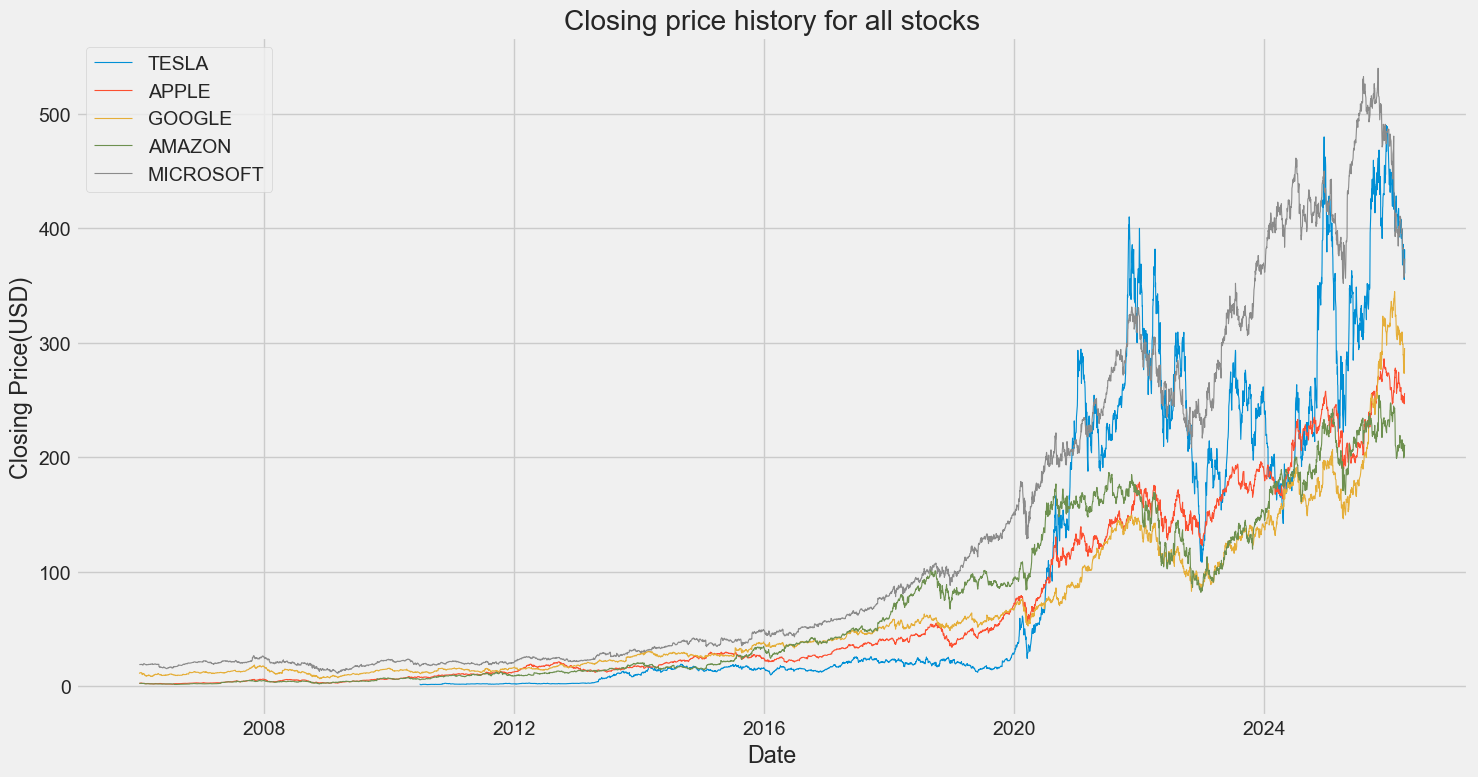

In [90]:
#Closing price over time for all companies
plt.figure(figsize=(15, 8))
for company, com_name in zip(comp_list, comp_name):
    plt.plot(company.index, company['Close'], label=com_name, linewidth=0.8)
plt.title('Closing price history for all stocks')
plt.xlabel('Date')
plt.ylabel('Closing Price(USD)')
plt.legend()
plt.tight_layout()
plt.show()

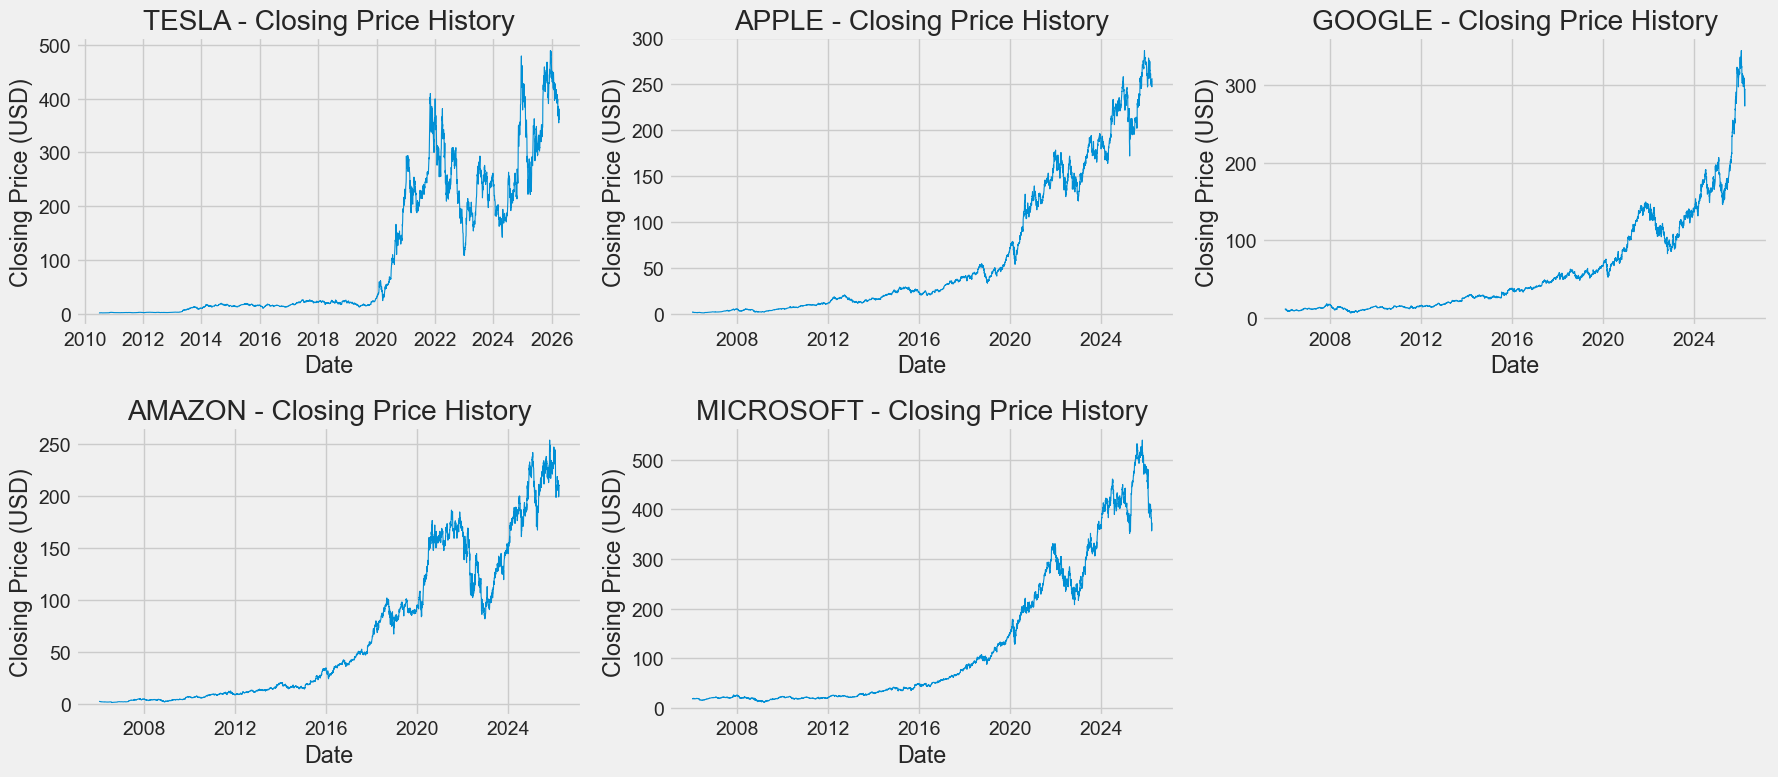

In [91]:
#Closing price over time for each companies
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))
axes = axes.flatten()

for i, (company, com_name) in enumerate(zip(comp_list, comp_name)):
    axes[i].plot(company.index, company['Close'], linewidth=0.8)
    axes[i].set_title(f'{com_name} - Closing Price History')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Closing Price (USD)')

axes[5].set_visible(False)  # hide empty 6th subplot
plt.tight_layout()
plt.show()

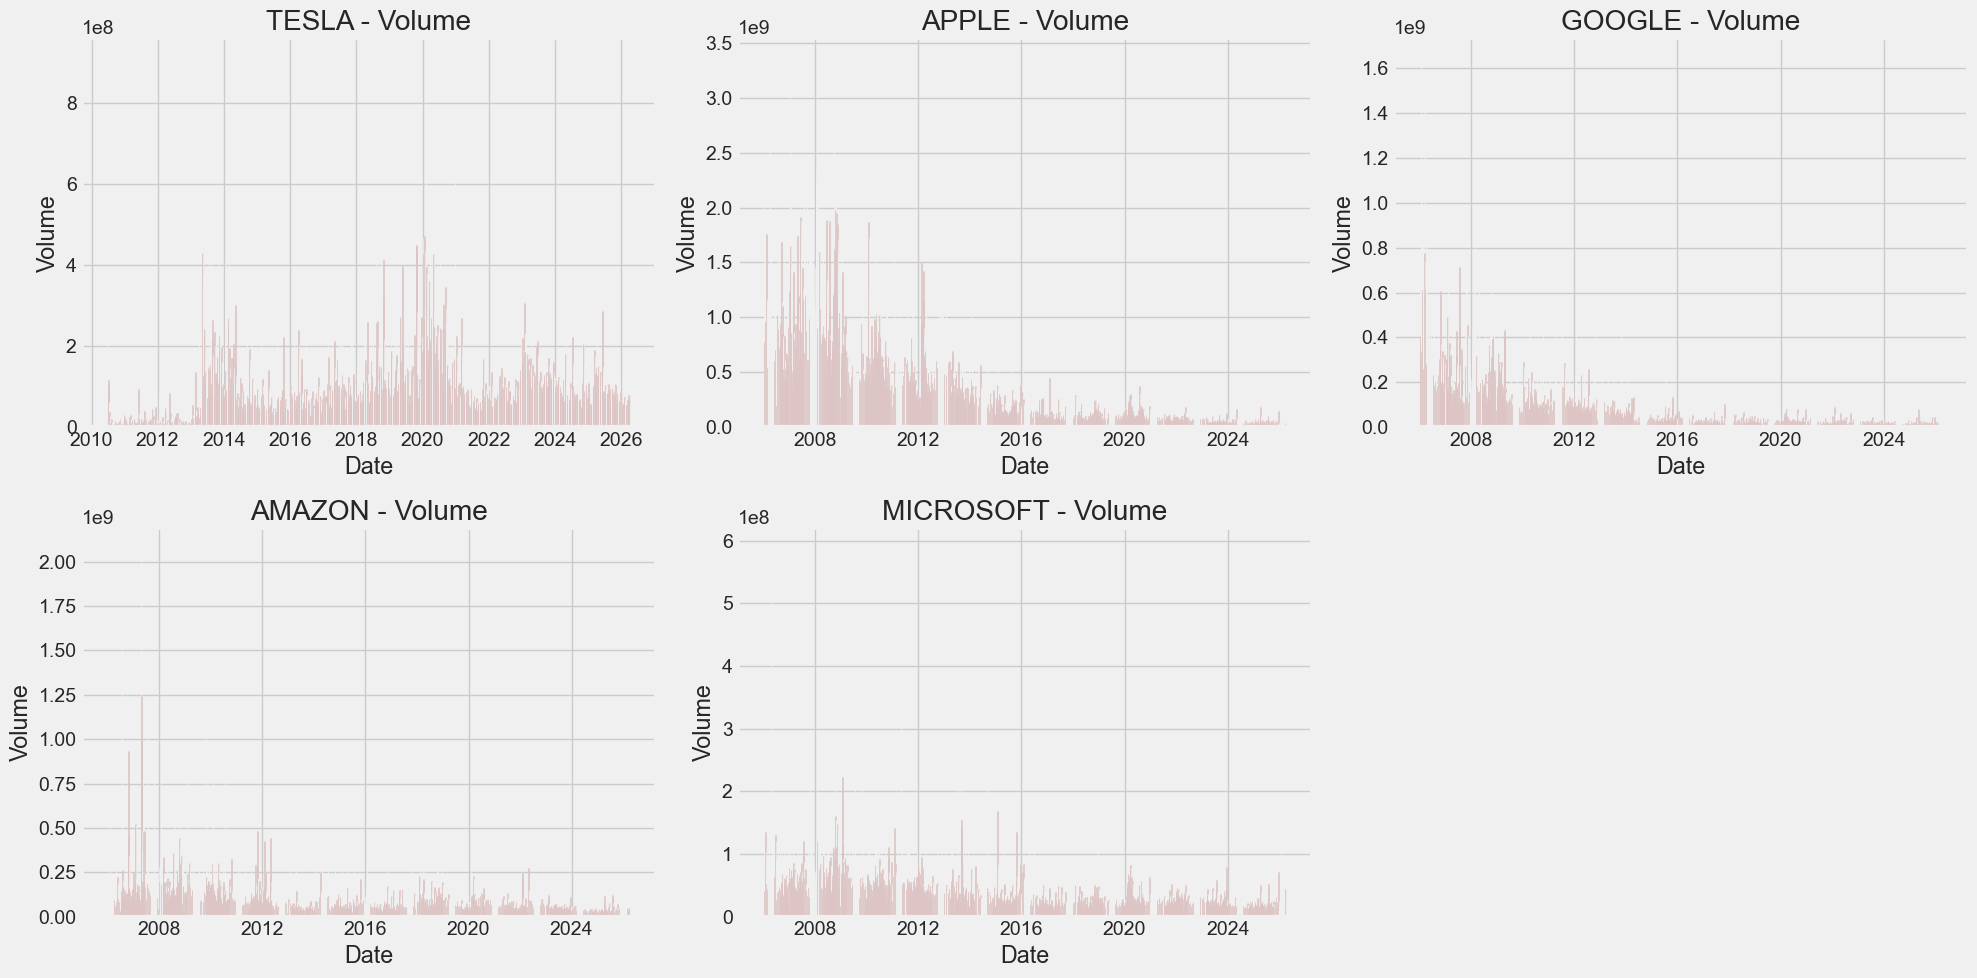

In [97]:
#Volume of sales over time
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20,10))
axes = axes.flatten()

for i, (company, com_name) in enumerate(zip(comp_list, comp_name)):
    axes[i].bar(company.index, company['Volume'], color='darkred', width=2)
    axes[i].set_title(f'{com_name} - Volume')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Volume')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

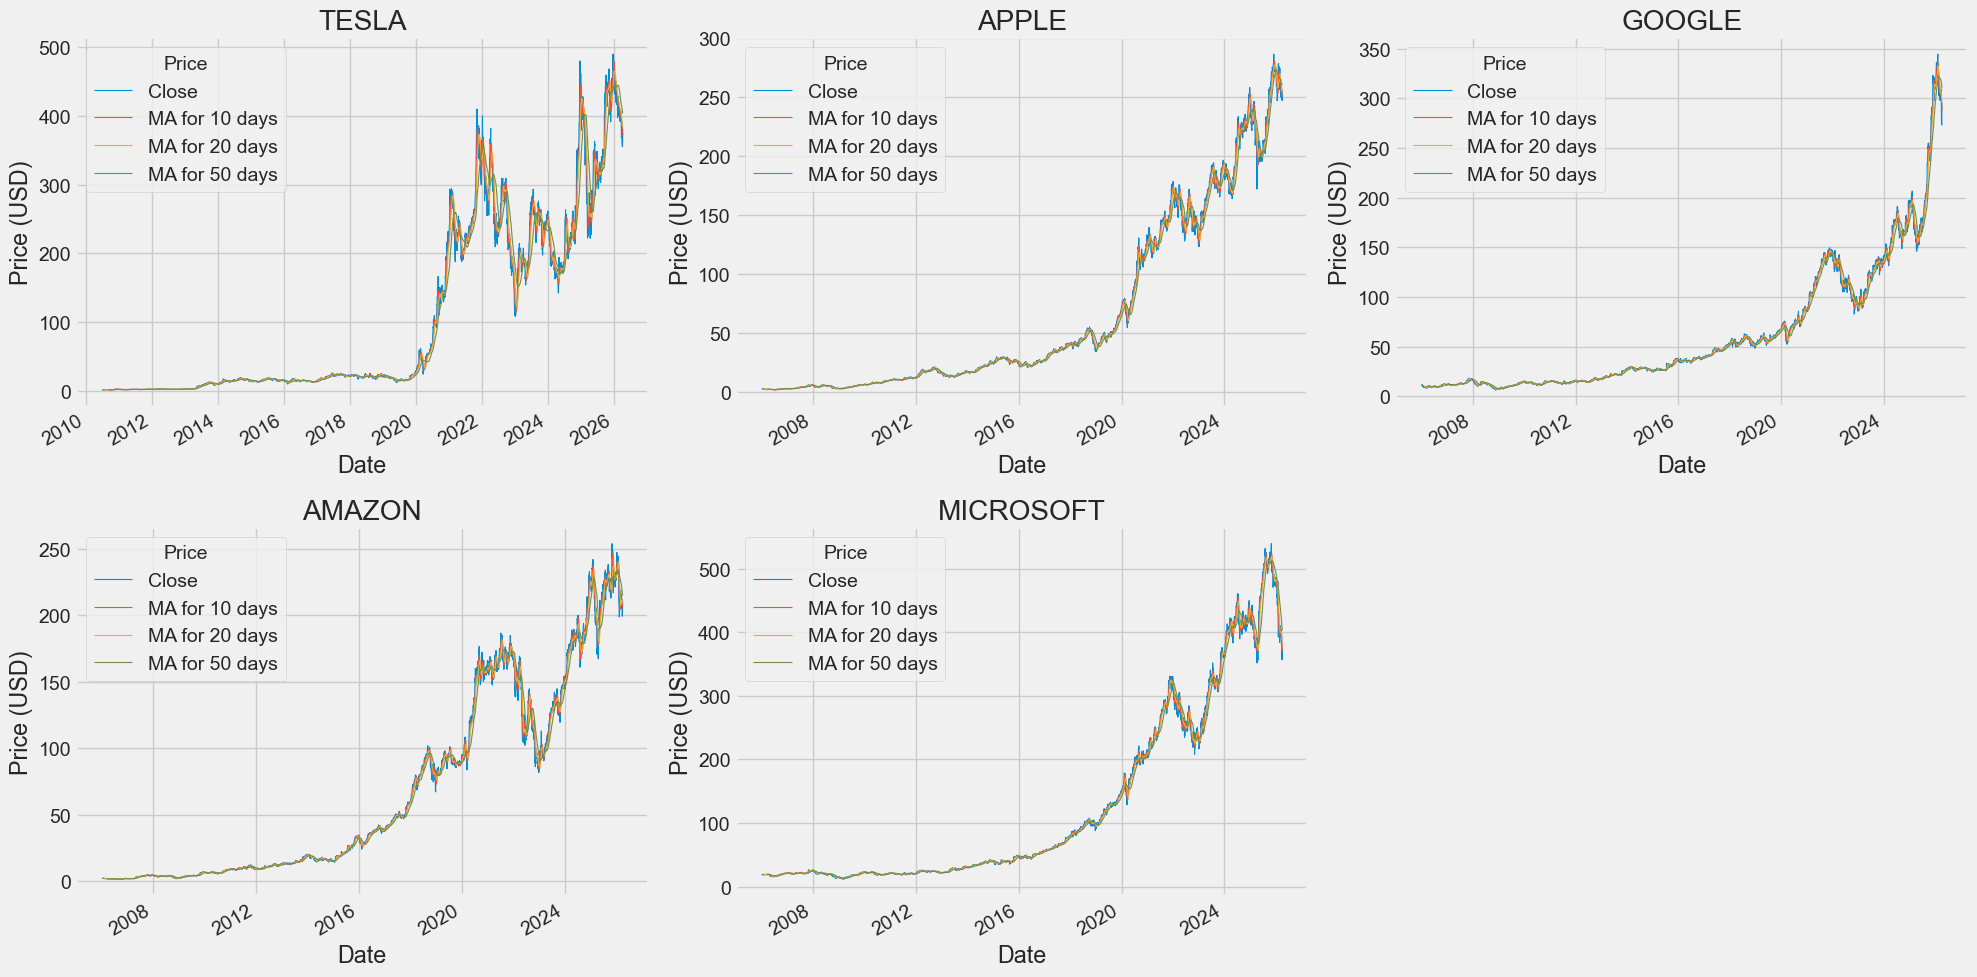

In [115]:
#Moving average for various Stocks

ma_day = [10, 20, 50]

for ma in ma_day:
    for company in comp_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Close'].rolling(ma).mean()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, (company, com_name) in enumerate(zip(comp_list, comp_name)):
    company[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[i], linewidth=0.8)
    axes[i].set_title(com_name)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price (USD)')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

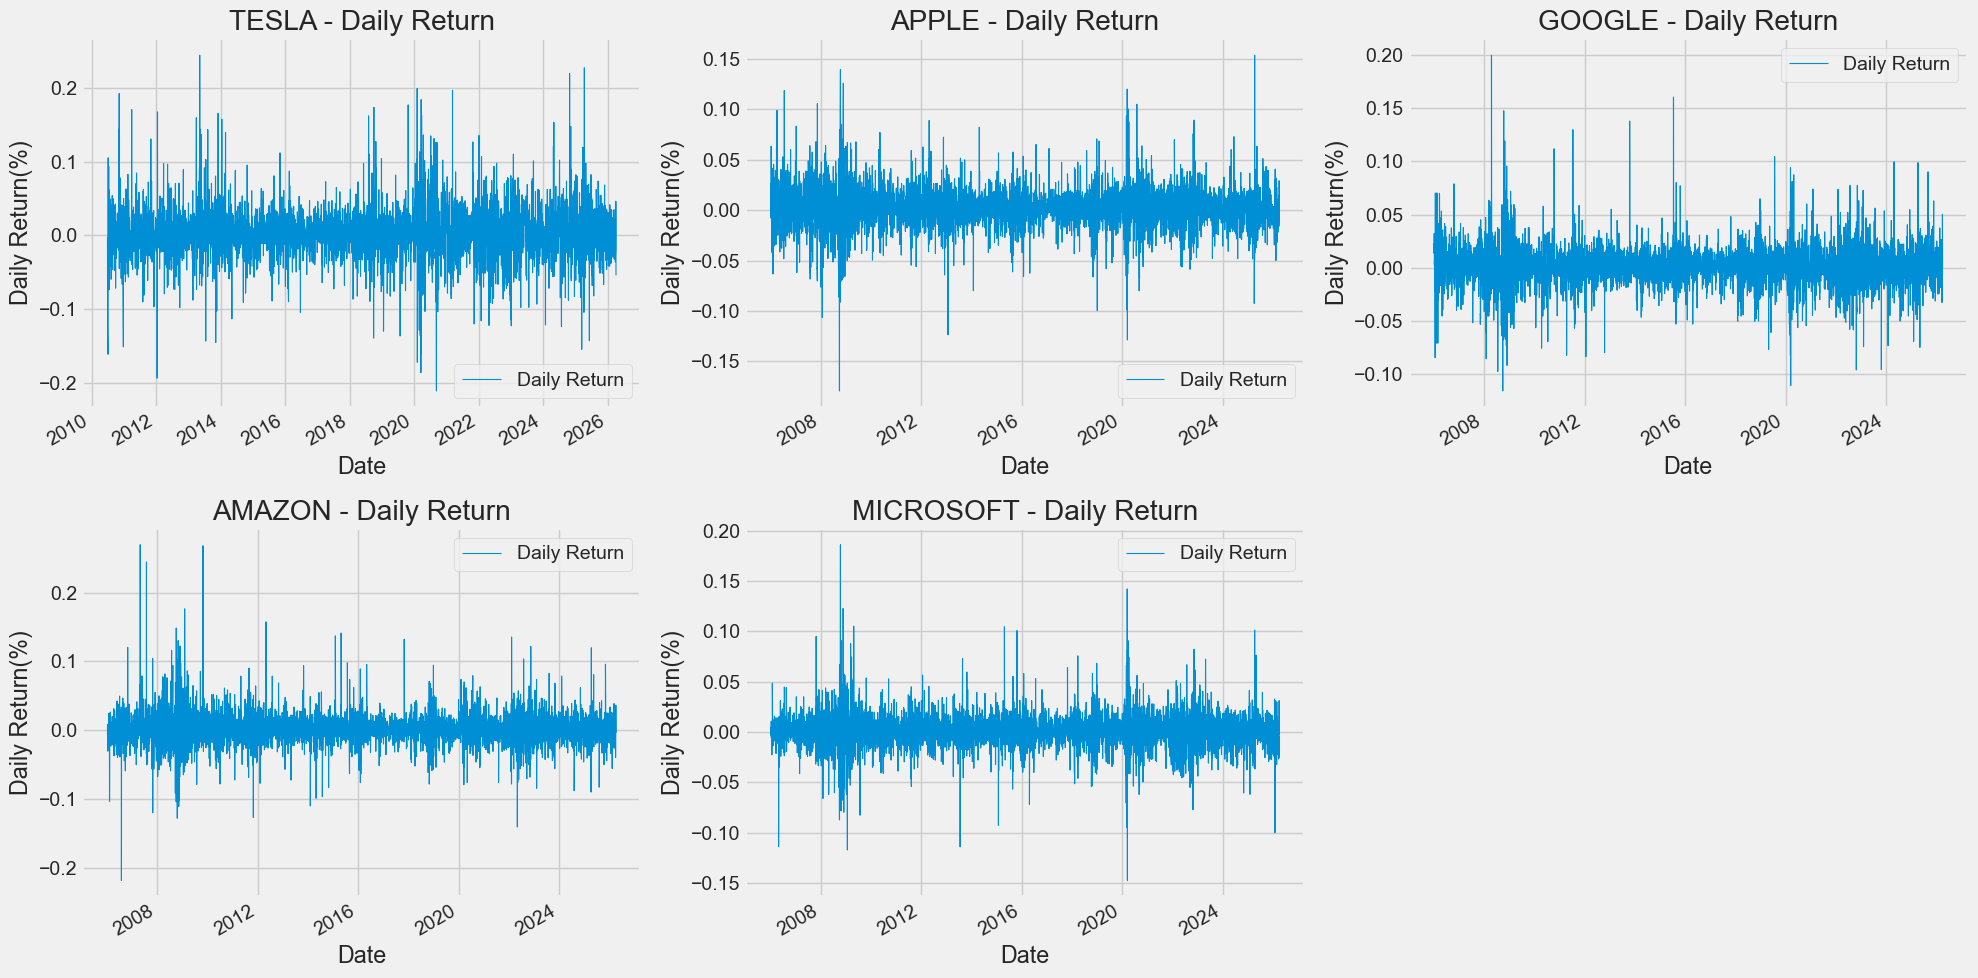

In [118]:
# Daily return for each stock
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20,10))
axes = axes.flatten()

for i, (company, com_name) in enumerate(zip(comp_list, comp_name)):
    company['Daily Return'] = company['Close'].pct_change()
    company['Daily Return'].plot(ax=axes[i], legend=True, linewidth=0.8)
    axes[i].set_title(f'{com_name} - Daily Return')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Daily Return(%)')
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

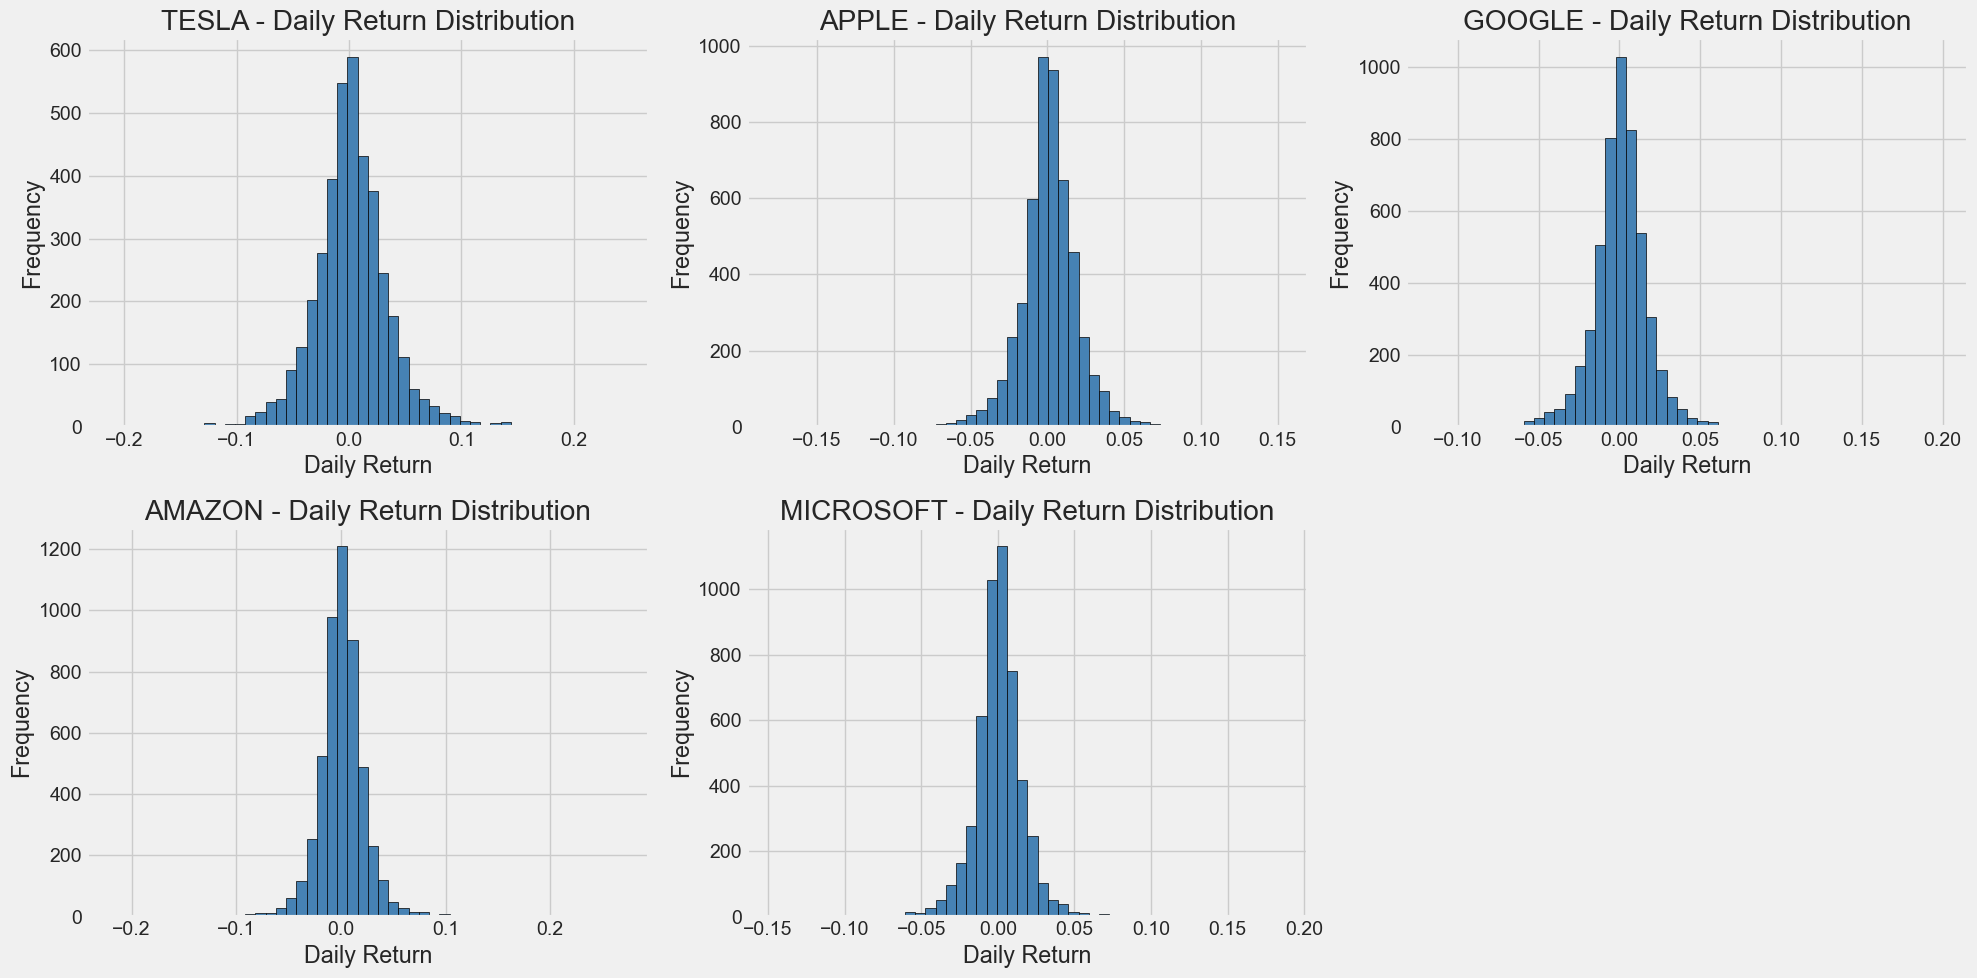

In [120]:
# Daily return distribution
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, (company, com_name) in enumerate(zip(comp_list, comp_name)):
    company['Daily Return'].hist(ax=axes[i], bins=50, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{com_name} - Daily Return Distribution')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Frequency')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

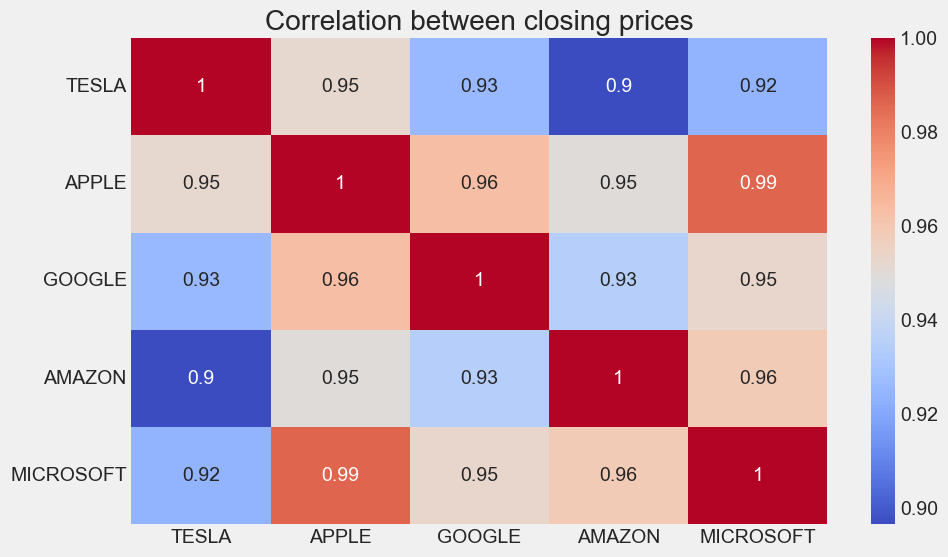

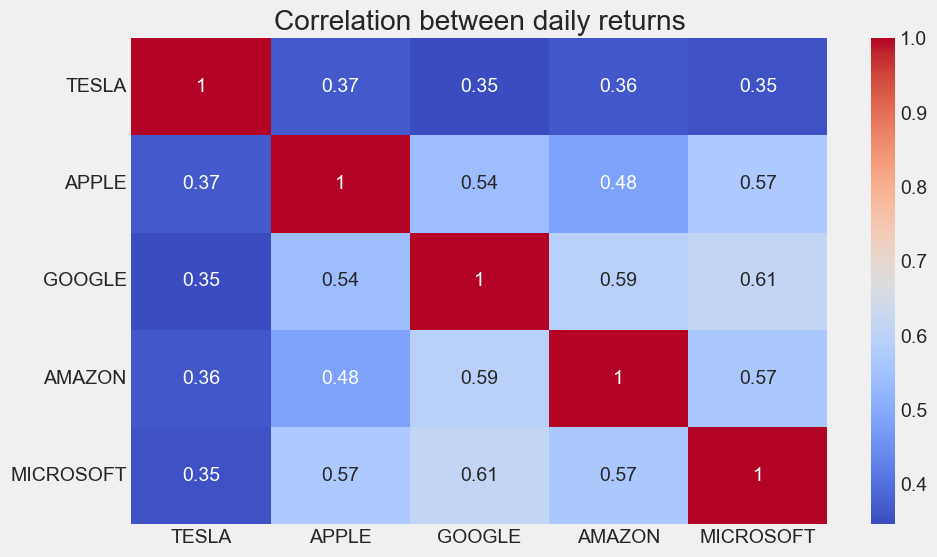

In [122]:
# Correlation between stocks
#1. Correlation in closing prices

closing_df = pd.concat([company['Close'].rename(com_name) for company, com_name in zip(comp_list, comp_name)], axis=1)

plt.figure(figsize=(10,6))
sns.heatmap(closing_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between closing prices')
plt.show()

#2. Correlation on daily returns
returns_df = closing_df.pct_change().dropna()

plt.figure(figsize=(10,6))
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between daily returns')
plt.show()

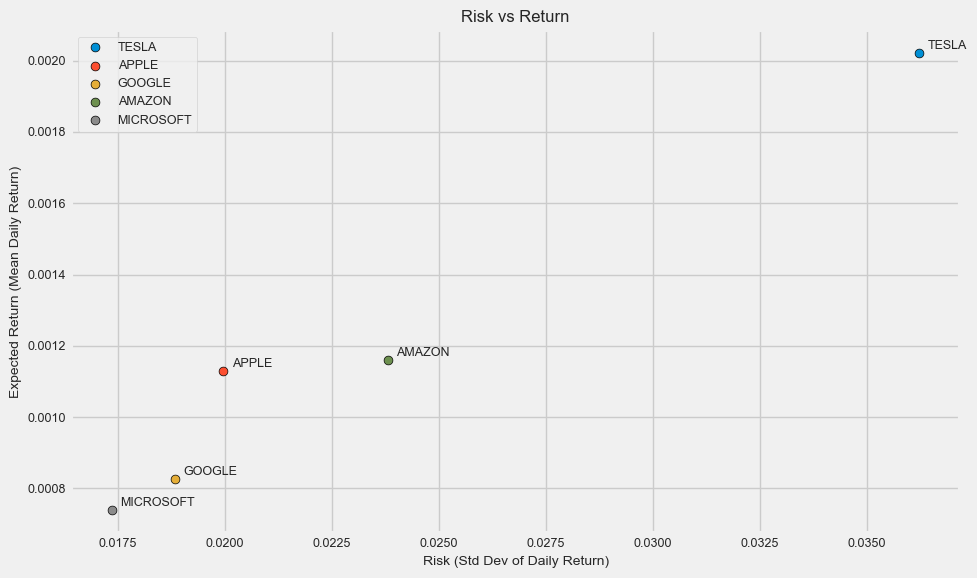

In [127]:
#Risk vs Return plots
plt.figure(figsize=(10, 6))

for com_name in comp_name:
    returns = closing_df[com_name].pct_change().dropna()
    plt.scatter(returns.std(), returns.mean(), label=com_name, s=40, edgecolors='black', linewidths=0.5)
    plt.annotate(com_name, (returns.std(), returns.mean()), 
                textcoords="offset points", xytext=(6, 3), fontsize=9)

plt.xlabel('Risk (Std Dev of Daily Return)', fontsize=10)
plt.ylabel('Expected Return (Mean Daily Return)', fontsize=10)
plt.title('Risk vs Return', fontsize=12)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

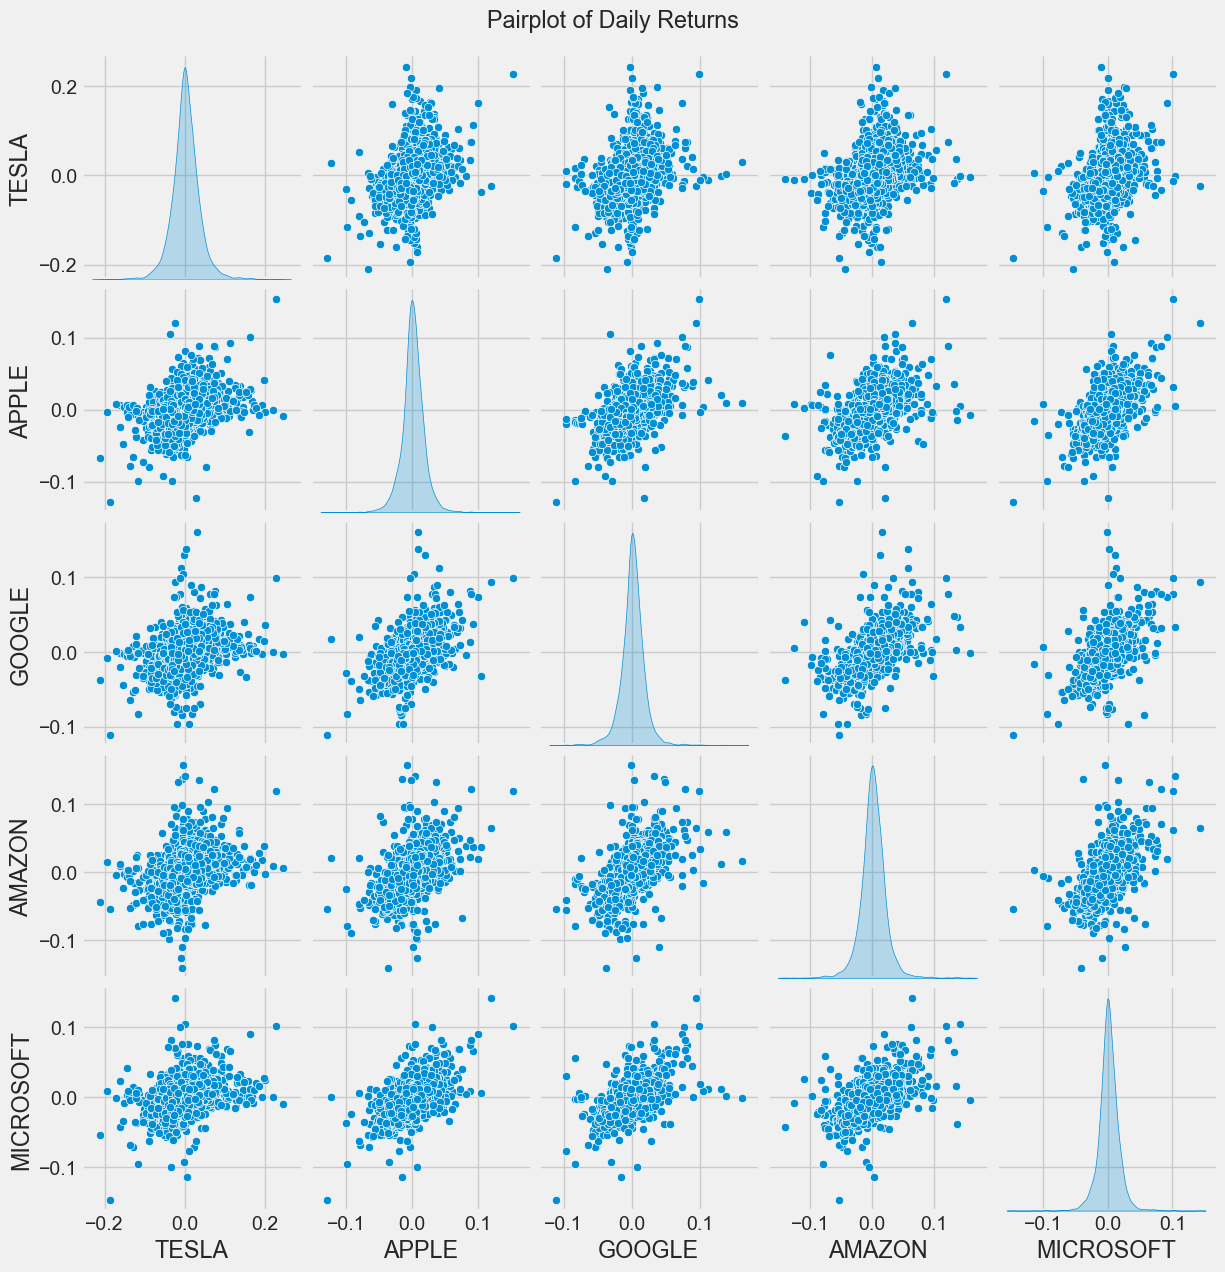

In [128]:
# Pairplots of daily returns
sns.pairplot(returns_df.dropna(), diag_kind='kde')
plt.suptitle('Pairplot of Daily Returns', y=1.02)
plt.show()

## Feature Engineering on Tesla

In [132]:
#Isolating Tesla stock
df_tsla = df[df['company_name'] == 'TESLA'].copy()
print(df_tsla.shape)
print(df_tsla.head())
print(df_tsla.tail())

(3965, 6)
               Close      High       Low      Open     Volume company_name
Date                                                                      
2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500        TESLA
2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500        TESLA
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000        TESLA
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000        TESLA
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500        TESLA
                 Close        High         Low        Open    Volume  \
Date                                                                   
2026-03-27  361.829987  369.859985  359.470001  369.690002  62065700   
2026-03-30  355.279999  367.290009  352.140015  365.859985  67954400   
2026-03-31  371.750000  373.329987  361.000000  361.510010  75534900   
2026-04-01  381.260010  383.140015  374.079987  378.630005  58683800   
2026-04-02  360.589996  370.27999

In [143]:
#Making of different features
#1. Moving Average
df_tsla['MA_10'] = df_tsla['Close'].rolling(10).mean()
df_tsla['MA_20'] = df_tsla['Close'].rolling(20).mean()
df_tsla['MA_50'] = df_tsla['Close'].rolling(50).mean()

#2.Daily return and volatility
df_tsla['Daily_Return'] = df_tsla['Close'].pct_change()
df_tsla['Volatility'] = df_tsla['Daily_Return'].rolling(20).std()

#3. RSI(Relative Strength Index)
delta = df_tsla['Close'].diff()
gain = delta.where(delta>0, 0).rolling(14).mean()
loss = -delta.where(delta<0, 0).rolling(14).mean()
rs = gain/loss
df_tsla['RSI'] = 100 - (100/(1+rs))

#4. MACD
ema12 = df_tsla['Close'].ewm(span=12, adjust=False).mean()
ema26 = df_tsla['Close'].ewm(span=26, adjust=False).mean()
df_tsla['MACD'] = ema12 - ema26
df_tsla['MACD_Signal'] = df_tsla['MACD'].ewm(span=9, adjust=False).mean()

#5. Bollinger Bands
df_tsla['BB_Middle'] = df_tsla['Close'].rolling(20).mean()
df_tsla['BB_Upper'] = df_tsla['BB_Middle'] + 2*df_tsla['Close'].rolling(20).std()
df_tsla['BB_Lower'] = df_tsla['BB_Middle'] - 2*df_tsla['Close'].rolling(20).std()

In [144]:
#Verifying all the features
print(df_tsla.columns.tolist())
print(df_tsla.shape)
df_tsla.tail()

['Close', 'High', 'Low', 'Open', 'Volume', 'company_name', 'MA_10', 'MA_20', 'Daily_Return', 'Volatility', 'RSI', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'MA_50']
(3965, 17)


,Close,High,Low,Open,Volume,company_name,MA_10,MA_20,Daily_Return,Volatility,RSI,MACD,MACD_Signal,BB_Middle,BB_Upper,BB_Lower,MA_50
Date,,,,,,,,,,,,,,,,,
2026-03-27,361.829987,369.859985,359.470001,369.690002,62065700,TESLA,381.963995,390.777998,-0.027626,0.022183,32.820515,-10.737555,-8.973140,390.777998,416.668245,364.887752,408.637198
2026-03-30,355.279999,367.290009,352.140015,365.859985,67954400,TESLA,377.935995,388.375998,-0.018102,0.022301,30.589905,-12.095063,-9.597525,388.375998,418.010125,358.741871,406.971398
2026-03-31,371.750000,373.329987,361.000000,361.510010,75534900,TESLA,375.183997,387.341998,0.046358,0.024594,35.111035,-11.706956,-10.019411,387.341998,417.811890,356.872107,405.656398
2026-04-01,381.260010,383.140015,374.079987,378.630005,58683800,TESLA,374.031998,386.107999,0.025582,0.023968,44.165324,-10.510837,-10.117696,386.107999,415.382085,356.833913,404.896599
2026-04-02,360.589996,370.279999,359.029999,364.200012,83031200,TESLA,372.060999,383.859999,-0.054215,0.026564,38.636867,-11.102816,-10.314720,383.859999,413.746539,353.973459,403.479598


In [146]:
#Checking for null values
print(df_tsla.isnull().sum())

Close            0
High             0
Low              0
Open             0
Volume           0
company_name     0
MA_10            9
MA_20           19
Daily_Return     1
Volatility      20
RSI             13
MACD             0
MACD_Signal      0
BB_Middle       19
BB_Upper        19
BB_Lower        19
MA_50           49
dtype: int64


In [148]:
#Dropping the null values
df_tsla.dropna(inplace=True)
print(df_tsla.shape)

(3916, 17)


## Data Preprocessing

In [149]:
#1. Selecting features for the model
features = ['Close', 'MA_10', 'MA_20', 'MA_50', 'Daily_Return', 'Volatility', 'RSI', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower']
data = df_tsla[features].values
print("Data Shape: ", data.shape)

Data Shape:  (3916, 11)


In [152]:
#2. Scaling the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
print("Scaled data shape:", scaled_data.shape)
print("Min:", scaled_data.min(), "Max:", scaled_data.max())

Scaled data shape: (3916, 11)
Min: 0.0 Max: 1.0000000000000002


In [153]:
#3. Creating sequences for LSTM
def create_sequences(data, sequence_length=60):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i]) #Taking last 60 days as input
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequence_length=60
X,y = create_sequences(scaled_data, sequence_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3856, 60, 11)
y shape: (3856,)


In [154]:
#4. Train/Test Split
split = int(0.8*len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (3084, 60, 11)
X_test shape:  (772, 60, 11)
y_train shape:  (3084,)
y_test shape:  (772,)


## Building a LSTM model

In [162]:
#Building the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,593 (213.25 KB)

 Non-trainable params: 0 (0.00 B)

## Training the model

In [163]:
#Trainig the model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0104 - val_loss: 0.0034
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 8.7912e-04 - val_loss: 0.0027
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 7.5868e-04 - val_loss: 0.0035
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 6.0148e-04 - val_loss: 0.0023
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 5.6929e-04 - val_loss: 0.0030
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 6.7319e-04 - val_loss: 0.0036
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 5.0705e-04 - val_loss: 0.0021
Epoch 8/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 4.8203e-04 - val_loss: 0.0026
Epoch 9/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 5.0197e-04 - val_loss: 0.0021
Epoch 10/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 3.8955e-04 - val_loss: 0.0021
Epoch 11/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 4.4274e-04 - val_loss: 0.0027
Epoch 12/100

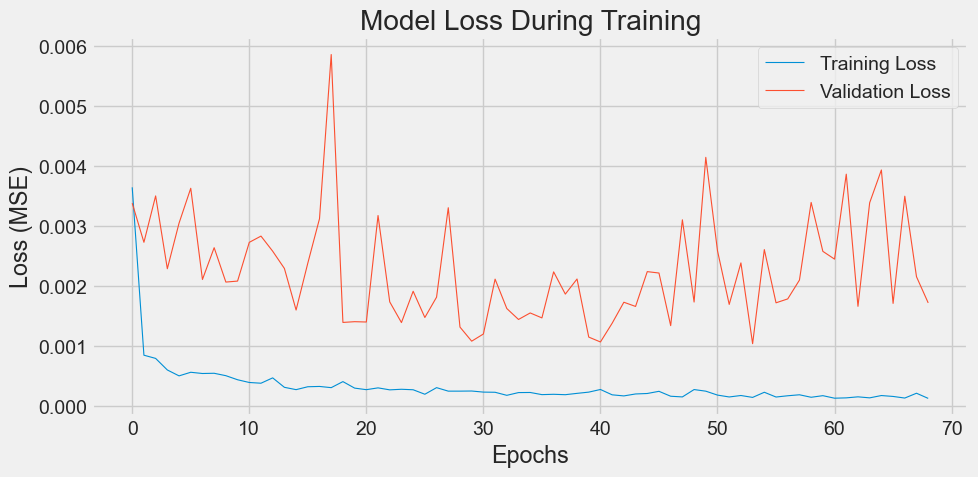

In [164]:
#Plotting Training loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=0.8)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=0.8)
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

In [167]:
#Making Predictions and Evalutate
predictions = model.predict(X_test)

#Inverse transform back to original price scale
pred_full = np.zeros((len(predictions), scaled_data.shape[1]))
pred_full[:, 0] = predictions[:, 0]
predicted_prices = scaler.inverse_transform(pred_full)[:, 0]

actual_full = np.zeros((len(y_test), scaled_data.shape[1]))
actual_full[:, 0] = y_test
actual_prices = scaler.inverse_transform(actual_full)[:, 0]

#Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
print(f"RMSE: ${rmse: .2f}")
print(f"MAE: ${mae: .2f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
RMSE: $ 21.59
MAE: $ 15.63


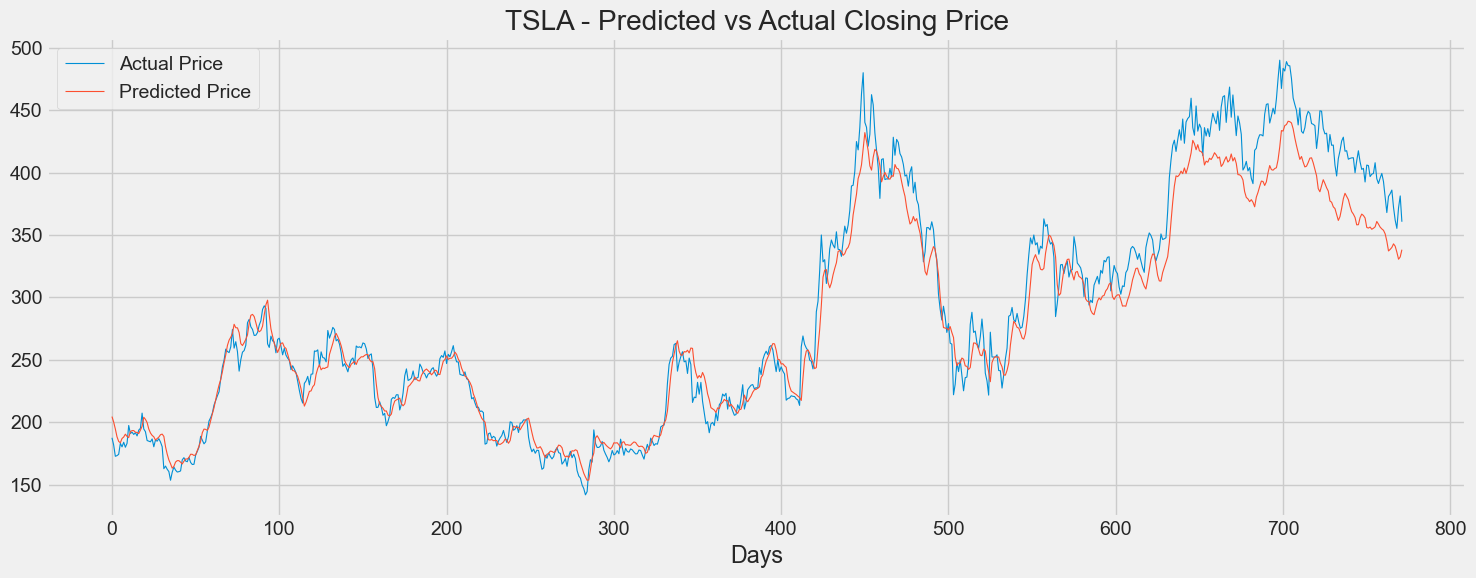

In [170]:
#Plotting predicted vs actual prices
plt.figure(figsize=(15,6))
plt.plot(actual_prices, label='Actual Price', linewidth=0.8)
plt.plot(predicted_prices, label='Predicted Price', linewidth=0.8)
plt.title('TSLA - Predicted vs Actual Closing Price')
plt.xlabel('Days')
plt.ylabel#('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [171]:
# Did the model predict the right direction (up or down)?
actual_direction = np.diff(actual_prices) > 0      # True if price went up
predicted_direction = np.diff(predicted_prices) > 0 # True if model predicted up

directional_accuracy = np.mean(actual_direction == predicted_direction) * 100
print(f"Directional Accuracy: {directional_accuracy:.2f}%")

Directional Accuracy: 49.29%


In [173]:
#Saving my model
model.save('tsla_lstm_model.keras')

import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [174]:
#Savinf df_tsla as a csv
df_tsla.to_csv('df_tsla.csv')